In [1]:
from arcs.generate import GraphGenerator
from importlib import resources
import copy 
import numpy as np 
import pandas as pd 

### 1. return a `pandas.DataFrame` instead of a graph from arcs.generate.GraphGenerator

here the table consists of :


| reaction_number | K | G | compound | 


where compound is -ve or +ve based on whether it is used up or generated respectively or 0 if not existing in that reaction


In [2]:
gg = GraphGenerator()
table = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=298,
    pressure=40,
    max_reaction_length=3,
    graph=False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:538: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [ ]:
table

### 2. Table Filtering

1. Filtering: 
    * a) filter reactions to show only those with species present in `initial_concentrations` (basic filter)

2. Sorting: 

    * b) filter based on availability (i.e. prioritise larger concentrations first) 

    > can be merged with (a) possibly?


    * c) filter based on stoichiometry (i.e. if you have `{O2:50,H2:100}` then 2H2 + O2 = 2H2O might be ranked higher)


    * d) filter based on simplicity (reactions with lots of molecules will be ranked lower - occams razor)


    * e) filter based on gibbs free energy (this could be moved forward)  

this should ideally lead to a scoring system which can be used to filter the table 

In [ ]:
# setup some initial concentrations 
# the idea is to try and predict 2H2 + O2 = 2H2O as top reaction  
concentrations = {k:0 for k in gg.compound_reference}
concentrations["H2O"] = 20
concentrations["H2"] = 20
concentrations["O2"] = 10 

#### a. filter reactions to show only those with species present in initial concentrations (basic filter)

need to make sure it filters sensibly, i.e. if we have a list of `[H2,O2,H2O]` we should make sure it finds reactions where equilibrium can be reached and not just reactions such as 

2 NO + O2 = 2 NO2 

which may come out just because of the presence of O2 

In [ ]:
# now for the function
# this should be put into `traversal.py` at a later date 

def filter_table_based_on_availability(
        table:pd.DataFrame,
        initial_concentrations:dict
) -> pd.DataFrame: 
    '''
    

    '''

    # get species present in initial concententrations
    present_species = [compound for compound,concentration in initial_concentrations.items() if concentration]

    #filter the reaction table to only show reactions that are possible
    reaction_data = ["K","G"]
    species_cols = [c for c in table.columns if c not in reaction_data]         

    disallowed = [c for c in species_cols if c not in present_species]         

    forward = (table[disallowed] >= 0).all(axis=1)   # disallowed never a          reactant
    reverse = (table[disallowed] <= 0).all(axis=1)   # disallowed never a          product
    filtered_table = table[forward | reverse]

    return filtered_table


filtered_table = filter_table_based_on_availability(table,concentrations)


In [ ]:
filtered_table[filtered_table != 0 ].dropna(axis=1,how="all")

### SANDBOXING PREVIOUS convert the dataframe to numpy 

In [ ]:
table_array = refactored_table.to_numpy(float)
table_array

1. Criterion 1: filter the reactions based on whether they are available or not 

need to make sure each mask has the same length (i.e. the total length of the dataframe)

In [ ]:
#probabilities of all the concentrations: 


In [ ]:
def get_probabilities(concentrations):
    '''
    create a mask based on all the concentrations (we need to know what is available to us)
    '''
    probabilities = np.array([v/sum(concentrations.values()) for v in concentrations.values()])
    return probabilities

probabilities = get_probabilities(concentrations)
probabilities > 0 

In [ ]:
def get_reaction_array(refactored_table,concentrations):
    '''
    take the pandas dataframe and only return the columns with species 
    '''
    return refactored_table[list(concentrations)].to_numpy(float)

species_reaction_array = get_reaction_array(refactored_table,concentrations)

In [ ]:
def get_gibbs_array(refactored_table):
    '''
    take the pandas dataframe and only return the columns with species 
    '''
    return refactored_table["G"].to_numpy(float)

gibbs_array = get_gibbs_array(refactored_table)

#### Criterion 1 : check whether all the reactants or products are available

(for now: reduce the table by this criterion )

In [ ]:
def filter_df_availability(refactored_table,concentrations):
    ps_conc = pd.Series(concentrations)
    avail = list(ps_conc[ps_conc > 0 ].index)

    df = refactored_table[avail]

    return refactored_table[
        np.any(
            df != 0 ,
            axis=1
        )
    ]

filtered_df = filter_df_availability(refactored_table,concentrations)

In [ ]:
def filtered_df_sensible(filtered_df,concentrations):
    ps_conc = pd.Series(concentrations)
    avail = list(ps_conc[ps_conc > 0 ].index)

    df = filtered_df.drop(columns=["G","K","G_rev","K_rev"])
    species = [c for c in df.columns] 
    missing = [ s for s in species if s not in avail]
    #needs_missing = (df[missing] < 0).any(axis=1)
    has_reactants = (df[avail] < 0 ).any(axis=1)
    has_products = (df[avail]>0).any(axis=1)
    fwd = ~(df[missing] < 0).any(axis=1)
    rev = ~(df[missing] > 0).any(axis=1)
    df = df[~fwd & has_reactants]+df[~rev & has_products]
    df["G"] = filtered_df["G"][df.index]
    df["K"] = filtered_df["K"][df.index]
    df["G_rev"] = filtered_df["G_rev"][df.index]
    df["K_rev"] = filtered_df["K_rev"][df.index]
    return df 


extra_filtered_df = filtered_df_sensible(filtered_df,concentrations)

In [ ]:
def filter_by_gibbs(extra_filtered_df):
    extra_filtered_df["G_abs"] = np.abs(extra_filtered_df["G"])
    return extra_filtered_df.sort_values(by="G_abs",ascending=False)

filter_by_gibbs(extra_filtered_df)

In [ ]:
from re import L


for i in list(extra_filtered_df.index):
    print(tabledict[i]["rstring"])

In [ ]:
#check whether reactants are available (every reactant must be available)
# should mass balance if not available i.e. you can have 1 product and 1 reactant but the atom types must be available
reactants = np.clip(-species_reaction_array,0,None) # make everything that is not a reactant 0 
reactants_mask = reactants > 0 

have_all_reactants_mask  = ((reactants_mask & ~present_mask).sum(axis=1) == 0) & reactants_mask.any(axis=1)    
have_all_reactants_mask[have_all_reactants_mask== True]

In [ ]:
#check whether products are available
products = np.clip(species_reaction_array,0,None) # make everything that is not a product 0 
products_mask = products > 0 
have_all_products_mask  = ((products_mask & ~present_mask).sum(axis=1) == 0) & products_mask.any(axis=1)    
have_all_products_mask[have_all_products_mask == True]

In [ ]:
total_mask = have_all_products_mask + have_all_reactants_mask
total_mask

##### Criterion 2 availability weighted by stoichiometry 

In [ ]:
# reactants
availability_r = reactants @ available_mask 
availability_r[have_all_reactants_mask]

In [ ]:
#products 
availability_p = products @ available_mask
availability_p[have_all_products_mask]

In [ ]:
availability = availability_r + availability_p

In [ ]:
def minmax(x):
    lo, hi = np.nanmin(x), np.nanmax(x)
    return np.zeros_like(x) if hi == lo else (x - lo) / (hi - lo)    

availability_score = minmax(availability)

In [ ]:
import numpy as np
import pandas as pd
###make chempy friendly concentrations dictionary 

def table_rank_reactions_2(_concentrations, refactored_df,w_gibbs=0.8,w_avail=0.6,w_simple=0.5):
    concentrations = copy.deepcopy(_concentrations)
    probabilities = {k: v / sum(concentrations.values())
                     for k, v in concentrations.items()}

    df = pd.DataFrame(refactored_df).fillna(0)

    species = [c for c in df.columns if c not in ["G", "K"]]
    avail = np.array([probabilities.get(s, 0.0) for s in species])
    present = avail > 0

    S     = df[species].to_numpy(float)
    gibbs = df['G'].to_numpy(float)    

    reac = np.clip(-S, 0, None)
    prod = np.clip( S, 0, None)    

    # --- Criterion 4: EVERY reactant must be present ---
    reac_mask = reac > 0
    have_all_r  = ((reac_mask & ~present).sum(axis=1) == 0) & reac_mask.any(axis=1)    

    prod_mask = prod > 0
    have_all_p  = ((prod_mask & ~present).sum(axis=1) == 0) & prod_mask.any(axis=1)    

    have_all = have_all_r + have_all_p

    # --- Criteria 2 & 3: reactant availability, weighted by stoichiometry ---
    availability_r = reac @ avail    ### ben:this takes reactions without all reactants
    availability_p = prod @ avail 
    availability = availability_r + availability_p

    print(have_all)

    def minmax(x):
        lo, hi = np.nanmin(x), np.nanmax(x)
        return np.zeros_like(x) if hi == lo else (x - lo) / (hi - lo)    

    # --- Criterion 1: Gibbs (most negative -> best) ---
    gibbs_term = 1 - minmax(gibbs)    

    # --- Criterion 5 (Occam): fewer/smaller coefficients -> simpler ---
    complexity  = np.abs(S).sum(axis=1)      # total molecules, both sides
    simple_term = 1 - minmax(np.log1p(complexity))   # log dampens huge outliers    

    #w_gibbs, w_avail, w_simple = 0.5, 0.45, 0.80    # <- three-way priority knob
    score = (w_gibbs * gibbs_term +
             w_avail * minmax(availability) +
             w_simple * simple_term)    

    def side(a):
        return " + ".join(f"{v:g} {s}" for s, v in zip(species, a) if v > 0)
    eqn = [f"{side(reac[i])} = {side(prod[i])}" for i in range(len(df))]    

    out = df.assign(reaction=eqn, availability=availability,
                    complexity=complexity, score=score)
    ranked = out.loc[have_all].sort_values('score', ascending=False)    

    assert ((reac[have_all] > 0) & ~present).sum() == 0, "infeasible reaction leaked into ranked!"

    return ranked 

ranked = table_rank_reactions_2(concentrations,refactored_table)

ranked.head(20)

### Todo 

1. figure out next stage of algorithm

    a) continue as normal ARCS algorithm:

        - random weighted choice of reaction
        - proceed down a random path 


    b) new algorithm:

        - randomly sample i.e. 1k times the ranked reactions here 
        - update concentrations 
        - generate a new ranked table, and sample that 1k times 
        - update concentrations 
        - do this N times until "converged" (if it does converge?)

### scenario 1 : continue as normal ARCS algorithm 

In [ ]:
from chempy.equilibria import Equilibrium, EqSystem
from chempy import Substance
import itertools as it 
import warnings 
import copy 

def choose_reaction(ranked_reactions: dict) -> int:
    """
    given a dictionary of ranked reactions from self.get_weighted_reaction_rankings
    chose a reaction based on weights and probabilities
    """
   #weights = {
   #     k: v["score"] for k, v in ranked_reactions.items()
   # }  # here higher is better
    weights = {k:1/v**2 for k,v in ranked_reactions["score"].items()}
    # added a square multiplier to force more the larger coefficients
    probabilities = {k: v / sum(weights.values())
                     for k, v in weights.items()}
    chosen_reaction = np.random.choice(
        [
            np.random.choice(
                a=list(probabilities.keys()),
                size=len(probabilities) * 10,
                p=list(probabilities.values()),
            )
        ][0]
    )
    return chosen_reaction

def generate_chempy_eqsystem(tabledict, index: int) -> EqSystem:
    """
    given a reaction index form a chempy.equilibria.EqSystem

    eventually this will be deprecated as it is a speed bottleneck

    needs to involve charged species

    """
    node_dict = tabledict[index]
    reactants = node_dict["reactants"]
    products = node_dict["products"]
    k = node_dict["K"]

    substances = {}
    for compound in list(it.chain(*[list(reactants) + list(products)])):
        substances[compound] = Substance.from_formula(
            compound, **{"charge": 0})

    equation = Equilibrium(reac=reactants, prod=products, param=k)
    try:
        return EqSystem([equation], substances=substances)
    except Exception:
        return None
    
def chempy_equilibrium_concentrations(
     concentrations: dict,
     equilibrium_reaction: EqSystem,
     chempy_sane=True,
 ) -> dict:
     """
     generate equilibrium concentrations
     if the reaction is "sane" and a "success" then it returns the equilibrium concentrations as a dict of concentrations
     elsewise
     return None
     """

     warnings.simplefilter("ignore")
     _concs = copy.deepcopy(concentrations)
     try:
         result = equilibrium_reaction.solve(init_concs=_concs)
         # assert result.success and result.sane
         if chempy_sane:
             assert result.success and result.sane
         else:
             assert result.success
         for compound, concentration in enumerate(result.conc):
             _concs[equilibrium_reaction.substance_names()[compound]
                    ] = concentration
         return _concs
     except Exception:
         return None

In [ ]:
###make chempy friendly concentrations dictionary 
concs = {'H2O':10,'SO2':9.6,'NO2':8.6}#,'NO':13,"O2":73}
updated_concs = concs 
species = [c for c in ranked.columns if c not in ["G","K"]]
updated_concs = defaultdict(dict)
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 


In [ ]:
### rank the reactions 
ranked_reactions = ranked.head(20)
chosen_reaction = choose_reaction(ranked_reactions.to_dict())

In [ ]:
### generate an chempy eqsystem 
eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
eqsystem 

In [ ]:
#generate updated concentrations 
new_concentrations = chempy_equilibrium_concentrations(concentrations=updated_concs,
                                  equilibrium_reaction=eqsystem,
                                  chempy_sane=True)

In [ ]:
###make chempy friendly concentrations dictionary 
concs = {"H2O":9.6,"SO2":9.6,"NO2":8.6}#,"NO":12,"O2":100}
species = [c for c in ranked.columns if c not in ["G","K","availability","score","complexity","reaction"]]
updated_concs = {}
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 


In [ ]:
# production run 
import tqdm 

def runner(updated_concs):
    reactionstats = {0:None}
    concentrations = {0:updated_concs}
    i=0
    for step in tqdm.tqdm(range(1,100)):
        _concentrations = copy.deepcopy(concentrations[i])
        ranked_reactions = table_rank_reactions_2(_concentrations,refactor).head(20)
        chosen_reaction = choose_reaction(ranked_reactions.to_dict())
        eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
        new_concentrations = chempy_equilibrium_concentrations(concentrations=_concentrations,
                                      equilibrium_reaction=eqsystem,
                                      chempy_sane=True)
        
        if new_concentrations: 
            i+=1 
            concentrations[i] = new_concentrations
            reactionstats[i] = {
                    "reaction":tabledict[chosen_reaction]["rstring"],
                    #"equilibrium_constant":tabledict[chosen_reaction]["K"]
            }
    return concentrations,reactionstats

concentrations,reactionstats = runner(updated_concs)

In [ ]:
from collections import Counter
pd.Series(Counter([x["reaction"] for x in reactionstats.values() if not x == None])).sort_values(ascending=False)

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.set_style("whitegrid")
fig,ax = plt.subplots(ncols=1,figsize=(10,5),dpi=150,sharey=True,sharex=True)

concdf = pd.DataFrame(concentrations).loc[["SO2","H2O","NO2","NO"]]
concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=ax,cmap="tab20")
#ax[0].set_xscale("log")
#ax[0].set_xlim(0,5)

### Scenario 2 - run all 1000 times then again then again until converged 

In [ ]:
# production run 
import tqdm 
import uncertainties as u

###make chempy friendly concentrations dictionary 
concs = {"H2O":41.9,"SO2":74.2,"NO2":226.3,"NO":206.6,"O2":154.9,"H2S":0}

species = [c for c in ranked.columns if c not in ["G","K","availability","score","complexity","reaction"]]
updated_concs = {}
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 

####
def runner_2(updated_concs):
    reactionstats = defaultdict(dict)
    concentrations = defaultdict(dict)
    reactionstats[0] = None 
    concentrations[0] = copy.deepcopy(updated_concs)
    
    for ii in tqdm.tqdm(range(1,100)):
        # 1. rank reactions based on original concentrations 
        _concentrations = copy.deepcopy(concentrations[ii-1]) # previous original 
        try:
            _concentrations = {k:v.n for k,v in _concentrations.items()}
        except:
            pass
        ranked_reactions = table_rank_reactions_2(_concentrations,refactor,w_gibbs=0.1,w_avail=0.1,w_simple=0.1).head(20)
        # 2. sample it 1000 times 
        sample_concentrations = {}
        sample_reaction_stats = []
        i=0
        for _ in range(0,200):
            # choose a reaction based on the ranked reactions 
            chosen_reaction = choose_reaction(ranked_reactions.to_dict()) 
            eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
            new_concentrations = chempy_equilibrium_concentrations(concentrations=_concentrations,
                                          equilibrium_reaction=eqsystem,
                                          chempy_sane=True)
            # if new_concentrations are not None (chempy_sane)
            if new_concentrations: 
                i+=1 
                sample_concentrations[i] = new_concentrations
                sample_reaction_stats.append(tabledict[chosen_reaction]["rstring"])
        
        sdf = pd.DataFrame(sample_concentrations)
        m = sdf.mean(axis=1)
        sem = sdf.std(axis=1)
        new = {}
        for name in m.index:
            new[name] = u.ufloat(m.T[name],sem.T[name]
                            )
        concentrations[ii] = new 

        #concentrations[ii] = pd.DataFrame(sample_concentrations).mean(axis=1).to_dict()
        reactionstats[ii] = Counter(sample_reaction_stats)
    return concentrations,reactionstats

concentrations,reactionstats = runner_2(updated_concs)

In [ ]:
_concentrations = {"NO2":10,"H2O":10,"SO2":10}

ranked_reactions = table_rank_reactions_2(_concentrations,refactor,w_gibbs=0.1,w_avail=0.1,w_simple=0.1).head(20)
ranked_reactions = ranked_reactions.loc[:, (ranked_reactions != 0).any(axis=0)]
ranked_reactions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
def nominal(x):
    return x.nominal_value if hasattr(x, "nominal_value") else x

def stddev(x):
    return x.std_dev if hasattr(x, "std_dev") else 0.0


sns.set_style("whitegrid")
fig,ax = plt.subplots(ncols=1,figsize=(10,5),dpi=150,sharey=False,sharex=True)

concdf = pd.DataFrame(concentrations).loc[["NO2","SO2","NO","H2S"]]

nominal_df = concdf.map(nominal)
std_df = concdf.map(stddev)


nominal_df.T.plot.line(ax=ax,yerr=std_df.T,cmap="tab20")#,marker='.')
ax.legend(ncols=3,bbox_to_anchor=[0.5,1])
#ax[0].set_xscale("log")
#ax[0].set_xlim(0,5)

In [ ]:
pd.Series(reactionstats[99]).sort_values(ascending=False)

In [ ]:
ps = pd.Series(concentrations[99])
ps[ps > 0].round(2)

### Against Jan Morten's data 

In [ ]:
def runner_2(updated_concs):
    reactionstats = defaultdict(dict)
    concentrations = defaultdict(dict)
    reactionstats[0] = None 
    concentrations[0] = copy.deepcopy(updated_concs)
    
    for ii in tqdm.tqdm(range(1,100)):
        # 1. rank reactions based on original concentrations 
        _concentrations = copy.deepcopy(concentrations[ii-1]) # previous original 
        ranked_reactions = table_rank_reactions_2(_concentrations,refactored_table).head(20)
        # 2. sample it 1000 times 
        sample_concentrations = {}
        sample_reaction_stats = []
        i=0
        for _ in range(0,200):
            # choose a reaction based on the ranked reactions 
            chosen_reaction = choose_reaction(ranked_reactions.to_dict()) 
            eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
            new_concentrations = chempy_equilibrium_concentrations(concentrations=_concentrations,
                                          equilibrium_reaction=eqsystem,
                                          chempy_sane=True)
            # if new_concentrations are not None (chempy_sane)
            if new_concentrations: 
                i+=1 
                sample_concentrations[i] = new_concentrations
                sample_reaction_stats.append(tabledict[chosen_reaction]["rstring"])    

        concentrations[ii] = pd.DataFrame(sample_concentrations).mean(axis=1).to_dict()
        reactionstats[ii] = Counter(sample_reaction_stats)
    return concentrations,reactionstats    

In [ ]:
# production run 
import tqdm 
###make chempy friendly concentrations dictionary 
concs = {
    "A":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
    "B-F":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":0},
    "G":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":5},
    "H":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
}
         

final_data = defaultdict(dict)

for conc_label,conc in concs.items():
    species = [c for c in ranked.columns if c not in ["G","K","availability","score","complexity","reaction"]]
    updated_concs = {}
    for spec in species:
        try:
            updated_concs[spec] = conc[spec]
        except Exception:
            updated_concs[spec] = 0     

    ####


    concentrations,reactionstats = runner_2(updated_concs)

    final_data[conc_label]["concentrations"] = concentrations
    final_data[conc_label]["reactionstats"] = reactionstats

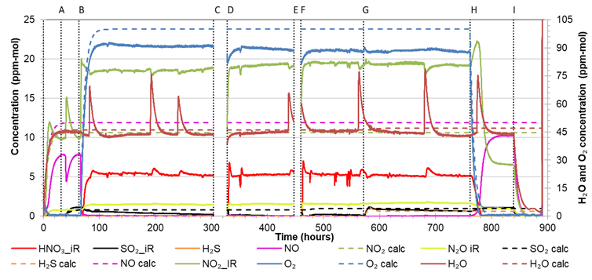

In [ ]:
experimental_data_1 = {
    "A": {
        "HNO3": {"x": [0, 100], "y": [concs["A"]["HNO3"], 0]},
        "NO2": {"x": [0, 100], "y": [concs["A"]["NO2"], 10]},
        "NO": {"x": [0, 100], "y": [concs["A"]["NO"], 8]},
        "SO2": {"x": [0, 100], "y": [concs["A"]["SO2"], 1]},
        "H2S": {"x": [0, 100], "y": [concs["A"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["A"]["N2O"], 1]}
    },
    "B-F": {
        "HNO3": {"x": [0, 100], "y": [concs["B-F"]["HNO3"], 5]},
        "NO2": {"x": [0, 100], "y": [concs["B-F"]["NO2"], 18]},
        "NO": {"x": [0, 100], "y": [concs["B-F"]["NO"], 0]},
        "SO2": {"x": [0, 100], "y": [concs["B-F"]["SO2"], 0]},
        "H2S": {"x": [0, 100], "y": [concs["B-F"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["B-F"]["N2O"], 1]}
    },
    "G": {
        "HNO3": {"x": [0, 100], "y": [concs["G"]["HNO3"], 5]},
        "NO2": {"x": [0, 100], "y": [concs["G"]["NO2"], 18]},
        "NO": {"x": [0, 100], "y": [concs["G"]["NO"], 0]},
        "SO2": {"x": [0, 100], "y": [concs["G"]["SO2"], 0.5]},
        "H2S": {"x": [0, 100], "y": [concs["G"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["G"]["N2O"], 1]}
    },
    "H": {
        "HNO3": {"x": [0, 100], "y": [concs["H"]["HNO3"], 0]},
        "NO2": {"x": [0, 100], "y": [concs["H"]["NO2"], 6]},
        "NO": {"x": [0, 100], "y": [concs["H"]["NO"], 10]},
        "SO2": {"x": [0, 100], "y": [concs["H"]["SO2"], 0]},
        "H2S": {"x": [0, 100], "y": [concs["H"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["H"]["N2O"], 0]}
    },
}

experimental_data_2 = {
    "A": {
        "H2O": {"x": [0, 100], "y": [concs["A"]["H2O"], 45]},
        "O2": {"x": [0, 100], "y": [concs["A"]["O2"], 0]}
    },
    "B-F": {
        "H2O": {"x": [0, 100], "y": [concs["B-F"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["B-F"]["O2"], 89]}
    },
    "G": {
        "H2O": {"x": [0, 100], "y": [concs["G"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["G"]["O2"], 89]}
    },
    "H": {
        "H2O": {"x": [0, 100], "y": [concs["H"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["H"]["O2"], 0]}
    }
}

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap

sns.set_style("whitegrid")
fig,axes = plt.subplots(ncols=len(final_data),figsize=(len(final_data)*5,5),dpi=150)

color1 = ["red","#2CA02C","tab:pink","black","orange","#98DF8A"]
colorcycler1 = LinearSegmentedColormap.from_list(
    "custom",color1
    )
color2 = ["brown","blue"]
colorcycler2 = LinearSegmentedColormap.from_list(
    "custom",color2
    )

for i,(label,data) in enumerate(final_data.items()):
    ax2 = axes[i].twinx()
    #axes[i].set_xscale("log")
    #ax2.set_xscale("log")
    concdf1 = pd.DataFrame(data["concentrations"]).loc[["HNO3","NO2","NO","SO2","H2S","N2O"]]
    concdf2 = pd.DataFrame(data["concentrations"]).loc[["H2O","O2"]]
    #concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=axes[i],cmap=colorcycler,marker='.')
    concdf1.T.plot.line(ax=axes[i],cmap=colorcycler1)#,marker='.')

    expdf1 = pd.DataFrame(experimental_data_1)
    for ii,compound in enumerate(expdf1["A"].keys()):
        axes[i].plot(expdf1[label][compound]["x"],expdf1[label][compound]["y"],linestyle="--",color=color1[ii])
    
    expdf2 = pd.DataFrame(experimental_data_2)
    for ii,compound in enumerate(expdf2["A"].keys()):
        ax2.plot(expdf2[label][compound]["x"],expdf2[label][compound]["y"],linestyle="--",color=color2[ii])   

    concdf2.T.plot.line(ax=ax2,cmap=colorcycler2)
    ax2.set_ylim(0,100)
    axes[i].set_ylim(0,25)
    axes[i].set_title(label)
    ax2.legend([],frameon=False)
    axes[i].legend([],frameon=False)
    axes[i].set_ylabel("ppm")
    ax2.set_ylabel("ppm (O2,H2O)")
    axes[i].set_xlabel("simulation step")




ln1 = ax2.get_legend_handles_labels() 
ln2  = axes[i].get_legend_handles_labels()
leg = ln1[0] + ln2[0]
lab = ln1[1] + ln2[1]


axes[0].legend(leg,lab,ncols=1,edgecolor="black",facecolor="white")
#ax[0].set_xlim(0,5)
plt.tight_layout()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap

sns.set_style("whitegrid")
fig,axes = plt.subplots(ncols=len(final_data),figsize=(len(final_data)*5,5),dpi=150,sharey=True)

colorcycler = LinearSegmentedColormap.from_list(
    "custom",["red","brown","blue","#2CA02C","tab:pink","black","orange","#98DF8A"]
    )

chosen = "HNO3"
color = "black"
for i,(label,data) in enumerate(final_data.items()):
    concdf = pd.DataFrame(final_data[label]["concentrations"]).loc[[chosen]]
    #concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=axes[i],cmap=colorcycler,marker='.')
    concdf.T.plot.line(ax=axes[i],color=color)#,marker='.')

    axes[i].set_title("label")
    axes[i].legend([],frameon=False)

axes[0].legend(ncols=1,edgecolor="black")
#ax[0].set_xscale("log")
axes[0].set_ylim(0,10)